In [1]:
!pip install -q optuna xgboost scikit-learn pandas matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.1 MB/s eta 0:00:00


In [2]:
DATA_PATH = "dataset/heart_statlog_cleveland_hungary_final.csv"

In [3]:
import os
import warnings
import numpy  as np
import pandas as pd

import optuna
import xgboost as xgb

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
)
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.compose         import ColumnTransformer
from sklearn.ensemble        import RandomForestClassifier, VotingClassifier
from sklearn.metrics         import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt   # inline in Colab by default

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("[✓] All libraries imported successfully.")

[✓] All libraries imported successfully.


In [4]:
RANDOM_STATE  = 42
TARGET        = "target"    # 1 = Disease, 0 = Healthy
TEST_SIZE     = 0.20
CV_FOLDS      = 5
N_OPTUNA_RF   = 80          # trials for Random Forest study
N_OPTUNA_XGB  = 80          # trials for XGBoost study  (mirrors Analysis notebook)

np.random.seed(RANDOM_STATE)

# Feature schema (mirrors Analysis/analysis_between_rf&XG.ipynb)
CATEGORICAL_FEATURES = [
    "sex",                  # 0 = Female, 1 = Male
    "chest pain type",      # 1-4 nominal
    "fasting blood sugar",  # binary
    "resting ecg",          # 0-2 ordinal
    "exercise angina",      # binary
    "ST slope",             # 0-2 ordinal
]

NUMERICAL_FEATURES = [
    "age",
    "resting bp s",
    "cholesterol",
    "max heart rate",
    "oldpeak",
]

print("[✓] Configuration set.")

[✓] Configuration set.


In [5]:
print("=" * 70)
print("  HEART DISEASE — Soft Voting Ensemble  (XGBoost + Random Forest)")
print("  Hyperparameter optimisation via Optuna  |  Metric: ROC-AUC")
print("=" * 70)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"\n[✗] Dataset not found: '{DATA_PATH}'\n"
        "    → Run Cell 2 to upload / point to the correct path."
    )

df = pd.read_csv(DATA_PATH)

print(f"\n[1/5] Dataset loaded")
print(f"      Shape         : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"      Missing values: {df.isnull().sum().sum()}")
print(f"      Target balance:\n"
      f"{df[TARGET].value_counts().rename({0:'No Disease', 1:'Disease'})}\n")

X_raw = df.drop(columns=[TARGET])
y     = df[TARGET]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,
)

print(f"[2/5] Train/Test split (80 / 20 stratified)")
print(f"      Train : {X_train_raw.shape[0]}  |  Test : {X_test_raw.shape[0]}")
print(f"      Train balance → {dict(y_train.value_counts())}")
print(f"      Test  balance → {dict(y_test.value_counts())}\n")


  HEART DISEASE — Soft Voting Ensemble  (XGBoost + Random Forest)
  Hyperparameter optimisation via Optuna  |  Metric: ROC-AUC

[1/5] Dataset loaded
      Shape         : 1190 rows × 12 columns
      Missing values: 0
      Target balance:
target
Disease       629
No Disease    561
Name: count, dtype: int64

[2/5] Train/Test split (80 / 20 stratified)
      Train : 952  |  Test : 238
      Train balance → {1: np.int64(503), 0: np.int64(449)}
      Test  balance → {1: np.int64(126), 0: np.int64(112)}



In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),                                  NUMERICAL_FEATURES),
        ("cat", OneHotEncoder(drop="first", sparse_output=False),  CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

X_train_proc = preprocessor.fit_transform(X_train_raw)
X_test_proc  = preprocessor.transform(X_test_raw)

cat_names     = (preprocessor
                 .named_transformers_["cat"]
                 .get_feature_names_out(CATEGORICAL_FEATURES)
                 .tolist())
FEATURE_NAMES = NUMERICAL_FEATURES + cat_names

print(f"[✓] Preprocessing complete  |  {len(FEATURE_NAMES)} features")
print(f"    Features: {FEATURE_NAMES}\n")



[✓] Preprocessing complete  |  16 features
    Features: ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak', 'sex_1', 'chest pain type_2', 'chest pain type_3', 'chest pain type_4', 'fasting blood sugar_1', 'resting ecg_1', 'resting ecg_2', 'exercise angina_1', 'ST slope_1', 'ST slope_2', 'ST slope_3']



In [7]:
def rf_objective(trial):
    """
    Optimise RandomForestClassifier hyperparameters.
    Tuned params (per spec): n_estimators, max_depth,
                              min_samples_split, min_samples_leaf
    Extra: max_features, class_weight='balanced' (stabilises small dataset).
    """
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators",       50, 500),
        "max_depth"        : trial.suggest_int("max_depth",           3,  20),
        "min_samples_split": trial.suggest_int("min_samples_split",   2,  20),
        "min_samples_leaf" : trial.suggest_int("min_samples_leaf",    1,  10),
        "max_features"     : trial.suggest_categorical("max_features",
                                                        ["sqrt", "log2"]),
        "class_weight"     : "balanced",
        "bootstrap"        : True,
        "random_state"     : RANDOM_STATE,
        "n_jobs"           : -1,
    }
    model  = RandomForestClassifier(**params)
    skf    = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True,
                              random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_proc, y_train,
                             cv=skf, scoring="roc_auc", n_jobs=-1)
    return scores.mean()


print("[3/5] Optuna – Random Forest hyperparameter search")
print(f"      Trials: {N_OPTUNA_RF}  |  CV folds: {CV_FOLDS}  |  Metric: ROC-AUC")

study_rf = optuna.create_study(
    direction  = "maximize",
    study_name = "random_forest_heart_hpo",
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_rf.optimize(rf_objective, n_trials=N_OPTUNA_RF, show_progress_bar=True)

# Merge search-space params with fixed params
best_rf_params = study_rf.best_params
best_rf_params.update({
    "class_weight": "balanced",
    "bootstrap"   : True,
    "random_state": RANDOM_STATE,
    "n_jobs"      : -1,
})

print(f"\n      [✓] Best CV ROC-AUC (RF) : {study_rf.best_value:.4f}")
print(f"      Best RF params          : {best_rf_params}\n")


[3/5] Optuna – Random Forest hyperparameter search
      Trials: 80  |  CV folds: 5  |  Metric: ROC-AUC


  0%|          | 0/80 [00:00<?, ?it/s]


      [✓] Best CV ROC-AUC (RF) : 0.9547
      Best RF params          : {'n_estimators': 491, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced', 'bootstrap': True, 'random_state': 42, 'n_jobs': -1}



In [8]:
def xgb_objective(trial):
    """
    Optimise XGBClassifier hyperparameters.
    Tuned params (per spec): n_estimators, max_depth, learning_rate,
                              subsample, colsample_bytree
    Extra params from Analysis notebook: min_child_weight, gamma,
                                          reg_alpha, reg_lambda
    """
    params = {
        "objective"        : "binary:logistic",
        "eval_metric"      : "logloss",
        "random_state"     : RANDOM_STATE,
        "n_estimators"     : trial.suggest_int  ("n_estimators",      50,  500),
        "max_depth"        : trial.suggest_int  ("max_depth",          3,   10),
        "learning_rate"    : trial.suggest_float("learning_rate",   0.01,  0.3,
                                                  log=True),
        "subsample"        : trial.suggest_float("subsample",        0.5,  1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5,  1.0),
        "min_child_weight" : trial.suggest_int  ("min_child_weight",   1,   10),
        "gamma"            : trial.suggest_float("gamma",             0,    5),
        "reg_alpha"        : trial.suggest_float("reg_alpha",         0,    1),
        "reg_lambda"       : trial.suggest_float("reg_lambda",       0.5,   5),
    }
    model  = xgb.XGBClassifier(**params, verbosity=0)
    skf    = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True,
                              random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_proc, y_train,
                             cv=skf, scoring="roc_auc", n_jobs=-1)
    return scores.mean()


print("[4/5] Optuna – XGBoost hyperparameter search")
print(f"      Trials: {N_OPTUNA_XGB}  |  CV folds: {CV_FOLDS}  |  Metric: ROC-AUC")

study_xgb = optuna.create_study(
    direction  = "maximize",
    study_name = "xgboost_heart_hpo",
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_xgb.optimize(xgb_objective, n_trials=N_OPTUNA_XGB, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({
    "objective"   : "binary:logistic",
    "eval_metric" : "logloss",
    "random_state": RANDOM_STATE,
})

print(f"\n      [✓] Best CV ROC-AUC (XGB): {study_xgb.best_value:.4f}")
print(f"      Best XGB params          : {best_xgb_params}\n")


[4/5] Optuna – XGBoost hyperparameter search
      Trials: 80  |  CV folds: 5  |  Metric: ROC-AUC


  0%|          | 0/80 [00:00<?, ?it/s]


      [✓] Best CV ROC-AUC (XGB): 0.9504
      Best XGB params          : {'n_estimators': 356, 'max_depth': 7, 'learning_rate': 0.127397824177842, 'subsample': 0.6148985575257964, 'colsample_bytree': 0.6639400789323814, 'min_child_weight': 1, 'gamma': 0.022904229688582595, 'reg_alpha': 0.7268865388800891, 'reg_lambda': 4.46727253981053, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42}



In [9]:
rf_opt  = RandomForestClassifier(**best_rf_params)
xgb_opt = xgb.XGBClassifier(**best_xgb_params, verbosity=0)

ensemble = VotingClassifier(
    estimators=[
        ("rf",  rf_opt),
        ("xgb", xgb_opt),
    ],
    voting="soft",      # averages predicted probabilities from both models
    n_jobs=-1,
)

print("[5/5] Training Soft-Voting Ensemble on full training set …")
ensemble.fit(X_train_proc, y_train)
print("      [✓] Ensemble trained.\n")


[5/5] Training Soft-Voting Ensemble on full training set …
      [✓] Ensemble trained.



In [10]:
y_pred = ensemble.predict(X_test_proc)
y_prob = ensemble.predict_proba(X_test_proc)[:, 1]

acc  = accuracy_score (y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score   (y_test, y_pred)
f1   = f1_score       (y_test, y_pred)
auc  = roc_auc_score  (y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)

print("=" * 60)
print("  SOFT-VOTING ENSEMBLE — EVALUATION RESULTS")
print("  (XGBoost-Optuna  +  RandomForest-Optuna,  voting='soft')")
print("=" * 60)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall*   : {rec:.4f}   ← critical for medical screening")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print()
print("  Confusion Matrix:")
print(f"    {cm}")
print()
print("  Classification Report:")
print(classification_report(y_test, y_pred,
                             target_names=["No Disease (0)", "Heart Disease (1)"]))
print("=" * 60)


  SOFT-VOTING ENSEMBLE — EVALUATION RESULTS
  (XGBoost-Optuna  +  RandomForest-Optuna,  voting='soft')
  Accuracy  : 0.9454
  Precision : 0.9380
  Recall*   : 0.9603   ← critical for medical screening
  F1-Score  : 0.9490
  ROC-AUC   : 0.9730

  Confusion Matrix:
    [[104   8]
 [  5 121]]

  Classification Report:
                   precision    recall  f1-score   support

   No Disease (0)       0.95      0.93      0.94       112
Heart Disease (1)       0.94      0.96      0.95       126

         accuracy                           0.95       238
        macro avg       0.95      0.94      0.95       238
     weighted avg       0.95      0.95      0.95       238



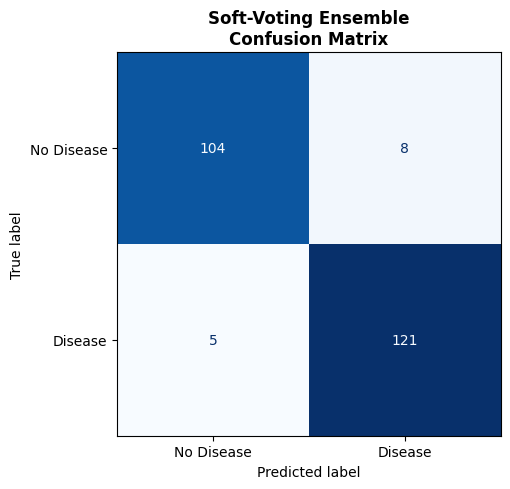

[✓] Plot saved → ensemble_confusion_matrix.png


In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ["No Disease", "Disease"],
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Soft-Voting Ensemble\nConfusion Matrix",
             fontsize=12, fontweight="bold")
ax.grid(False)
plt.tight_layout()
plt.savefig("ensemble_confusion_matrix.png", bbox_inches="tight", dpi=130)
plt.show()
print("[✓] Plot saved → ensemble_confusion_matrix.png")

In [12]:
sep = "-" * 60
print(sep)
print("  BEST HYPERPARAMETERS  (copy-paste ready)")
print(sep)

print("\n  ── Random Forest ──")
for k, v in best_rf_params.items():
    print(f"    {k:25s}: {v}")

print("\n  ── XGBoost ──")
for k, v in best_xgb_params.items():
    print(f"    {k:25s}: {v}")

print(sep)

------------------------------------------------------------
  BEST HYPERPARAMETERS  (copy-paste ready)
------------------------------------------------------------

  ── Random Forest ──
    n_estimators             : 491
    max_depth                : 15
    min_samples_split        : 3
    min_samples_leaf         : 1
    max_features             : sqrt
    class_weight             : balanced
    bootstrap                : True
    random_state             : 42
    n_jobs                   : -1

  ── XGBoost ──
    n_estimators             : 356
    max_depth                : 7
    learning_rate            : 0.127397824177842
    subsample                : 0.6148985575257964
    colsample_bytree         : 0.6639400789323814
    min_child_weight         : 1
    gamma                    : 0.022904229688582595
    reg_alpha                : 0.7268865388800891
    reg_lambda               : 4.46727253981053
    objective                : binary:logistic
    eval_metric              : lo